## PROJECT: Advanced Feature Engineering + ML Pipeline (Telco)

### 🔹 1. Problem Statement

Predict customer churn using advanced feature engineering and a scalable machine learning pipeline.

### 🔹 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Models
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

### 🔹 3. Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/telco-customer-churn.csv"
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 🔹 4. Data Cleaning

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df = df.drop('customerID', axis=1)

### 🔹 5. Feature Engineering (ADVANCED)

In [4]:
# Average monthly charges
df['AvgCharges'] = df['TotalCharges'] / (df['tenure'] + 1)

# Tenure groups
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-1yr','1-2yr','2-4yr','4-6yr']
)

# High spending flag
df['HighSpender'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

### 🔹 6. Define Features

In [5]:
X = df.drop('Churn', axis=1)
y = df['Churn']

### 🔹 7. Identify Column Types

In [6]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

### 🔹 8. Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 🔹 9. Build Preprocessing Pipeline

In [8]:
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

### 🔹 10. Full ML Pipeline

In [9]:
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

### 🔹 11. Hyperparameter Tuning (GridSearchCV)

In [10]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'AvgCharges', 'HighSpender'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         Index(...
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TenureGroup'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

### 12. Best Model

In [11]:
best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}


### 13. Evaluation

In [12]:
y_pred = best_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[926 107]
 [192 182]]

Classification Report:
               precision    recall  f1-score   support

          No       0.83      0.90      0.86      1033
         Yes       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



### 14. ROC-AUC Curve

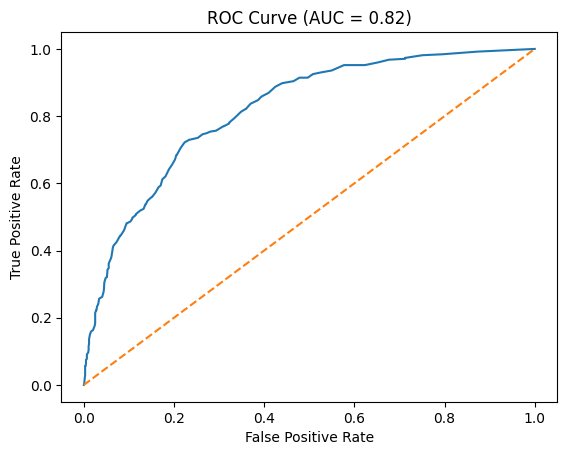

In [13]:
y_prob = best_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test.map({'No':0, 'Yes':1}), y_prob)

fpr, tpr, _ = roc_curve(y_test.map({'No':0, 'Yes':1}), y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.2f})")
plt.show()

### 15. Feature Importance

In [14]:
# Extract model
rf = best_model.named_steps['model']

# Get feature names
encoded_features = best_model.named_steps['preprocessing'].get_feature_names_out()

# Importance
importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': encoded_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
3,num__TotalCharges,0.145553
1,num__tenure,0.135494
4,num__AvgCharges,0.131529
2,num__MonthlyCharges,0.130446
12,cat__InternetService_Fiber optic,0.036444
30,cat__PaymentMethod_Electronic check,0.033458
6,cat__gender_Male,0.023851
27,cat__Contract_Two year,0.023820
15,cat__OnlineSecurity_Yes,0.023253
28,cat__PaperlessBilling_Yes,0.021991


### 16. Plot Feature Importance

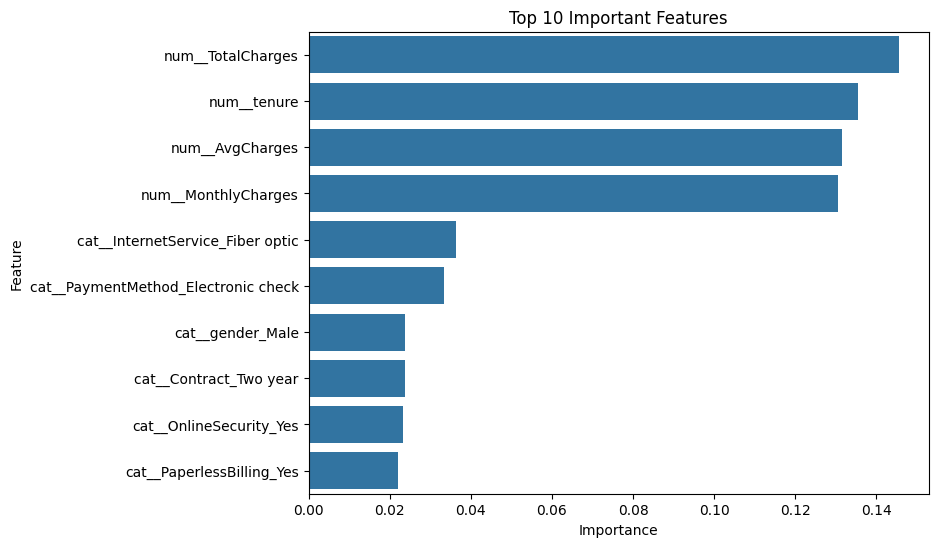

In [15]:
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title("Top 10 Important Features")
plt.show()

### 17. Key Insights
Feature engineering improved model performance

AvgCharges and tenure-based features are strong predictors

Random Forest performs best after tuning

ROC-AUC shows strong classification ability

### 18. Business Recommendations
Target high monthly charge customers with low tenure

Focus retention on high-risk segments

Offer long-term contracts for stability

### 19. Conclusion
This project demonstrates how feature engineering and ML pipelines improve prediction performance and create scalable solutions.